In [ ]:
"""
05_compute_profile_similarity.ipynb
==================================
Similarity Metrics & Drug Effectiveness Scoring. The central output — quantifying how much each drug shifts the phenotype from negcon toward poscon.
Follows Step 4 of the analysis pipeline.
TODO: implemented similarity metric 4b; implement other similarity metrics 

Inputs:
    - outputs/01_preprocessed_features.csv
    - outputs/02_pca_profiles.csv (for similarity metrics that use PCA)
    - outputs/02_plate_selected_features.json (selected features per plate, for metrics that don't use PCA)

Outputs:
    - TBD
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [274]:
OUTPUT_DIR = Path("../outputs")
df_all = pd.read_csv(OUTPUT_DIR / "01_preprocessed_features.csv")
df_pca = pd.read_csv(OUTPUT_DIR / "02_pca_profiles.csv")

meta_cols = ["plate", "session", "batch", "row", "column", "compound", "dose_uM", "cell_type", "condition", "num_wells"]

In [284]:
def calculate_nmi(df, n_pcs=None, level='plate'):
    # 1. Define metadata and features (Same as before)
    meta_cols = ["plate", "session", "batch", "row", "column", "compound", "dose_uM", "cell_type", "condition", "num_wells"]
    cols = [f'PC{i+1}' for i in range(n_pcs)] if n_pcs else [c for c in df.columns if c not in meta_cols]
    
    print(f"Using {len(cols)} dimensions for NMI calculation...")

    # 2. Define the grouping level
    groups = df.groupby('plate') if level == 'plate' else [("Global", df)]

    all_results = []

    for label, group_df in groups:
        healthy = group_df[group_df['condition'] == 'healthy'][cols]
        disease = group_df[group_df['condition'] == 'disease'][cols]
        
        if len(healthy) < 2 or len(disease) < 2:
            continue 

        # 1. Define the rescue axis (vector from disease to healthy)
        mu_h, mu_d = healthy.mean().values, disease.mean().values
        direction_vec = mu_h - mu_d
        max_dist = np.linalg.norm(direction_vec)
        
        if max_dist == 0: continue
            
        unit_vec = direction_vec / max_dist
        coords = group_df[cols].values
        
        # 2. Project all points onto the axis
        nmi_values = np.dot(coords - mu_d, unit_vec) / max_dist
        mi_values = np.dot(coords - ((mu_h + mu_d) / 2), unit_vec)
        
        # 3. Flip if needed (standardize "Healthy" = Positive)
        if nmi_values[group_df['condition'] == 'healthy'].mean() < nmi_values[group_df['condition'] == 'disease'].mean():
            nmi_values, mi_values = -nmi_values, -mi_values
        
        # 4. Calculate Z-Factor (using finalized MI scores)
        h_scores = nmi_values[group_df['condition'] == 'healthy']
        d_scores = nmi_values[group_df['condition'] == 'disease']
        z_factor = 1 - (3 * (np.std(h_scores) + np.std(d_scores)) / np.abs(np.mean(h_scores) - np.mean(d_scores)))

        # 5. Calculate residuals (distance off line)
        # Projected point is Disease_mean + (NMI * Vector_from_disease_to_healthy)
        proj = mu_d + (nmi_values[:, np.newaxis] * direction_vec)
        # Residual = Euclidean distance between actual point and projected point
        residuals = np.linalg.norm(coords - proj, axis=1)
        
        # 6. Save and print output
        res = group_df.copy()
        res['MI'], res['NMI'], res['z_factor'], res['residuals'] = mi_values, nmi_values, z_factor, residuals
        
        print(f"  {label} Results → Z-Factor: {z_factor:.3f}")
        
        all_results.append(res)

    return pd.concat(all_results)

def plot_nmi_summary(df_nmi):
    np.random.seed(2026) # random seed is to control the jitter when points overlap
    fig, ax = plt.subplots(figsize=(15, 7))
    
    # 1. Setup groups and colors
    order = ['disease', 'treatment', 'healthy']
    treat_df = df_nmi[df_nmi['condition'] == 'treatment'].copy()
    
    unique_cpds = sorted(treat_df['compound'].unique())
    cpd_colors = sns.color_palette("husl", len(unique_cpds))
    cpd_map = dict(zip(unique_cpds, cpd_colors))

    # 2. Boxplot
    sns.boxplot(data=df_nmi, x='condition', y='NMI', 
                hue='condition', palette={'healthy': 'black', 'disease': 'red', 'treatment': '#eeeeee'}, 
                order=order, width=0.4, ax=ax, fliersize=0, boxprops=dict(alpha=0.2), 
                zorder=1, legend=False)

    # 3. Stripplot for controls
    controls = df_nmi[df_nmi['condition'] != 'treatment']
    sns.stripplot(data=controls, x='condition', y='NMI', hue='condition', 
                  palette={'healthy': 'black', 'disease': 'red'}, 
                  order=order, size=7, jitter=0.2, alpha=0.5, edgecolor='white', 
                  linewidth=1, ax=ax, zorder=2, legend=False)

    # 4. Custom Scatter for Treatment (color by dose and compound)
    if not treat_df.empty:
        x_base = 1 
        
        for cpd in unique_cpds:
            # Subset data for this specific compound
            cpd_data = treat_df[treat_df['compound'] == cpd].copy()
            color = cpd_map[cpd]
            
            # Normalize Dose scale for this compound
            doses = cpd_data['dose_uM'].values
            if len(np.unique(doses)) > 1:
                d_min, d_max = doses.min(), doses.max()
                # Scale between 0.25 (low dose) and 0.9 (high dose)
                alphas = 0.25 + (0.65 * (doses - d_min) / (d_max - d_min))
            else:
                alphas = np.full(len(doses), 0.7) # Default if only one dose exists
            
            jitter = np.random.uniform(-0.1, 0.1, size=len(cpd_data))
            
            # Plot each well with its specific alpha
            for i in range(len(cpd_data)):
                ax.scatter(x_base + jitter[i], cpd_data.iloc[i]['NMI'], 
                           color=color, 
                           alpha=alphas[i], 
                           s=70, edgecolor='white', linewidth=0.5, zorder=3)
            
            # Create dummy entry for a solid legend
            ax.scatter([], [], color=color, label=cpd, s=70, alpha=0.8)

    # 5. Styling
    ax.axhline(1.0, color='black', linestyle='--', alpha=0.4)
    ax.axhline(0.0, color='red', linestyle='--', alpha=0.4)

    z_fac = df_nmi['z_factor'].mean()
    unique_plates = df_nmi['plate'].unique()
    title_id = f"Plate: {unique_plates[0]}" if len(unique_plates) == 1 else f"Global ({len(unique_plates)} Plates)"

    ax.set_title(f"{title_id}: Rescue Efficiency (NMI)\n", fontsize=14, fontweight='bold')
    ax.text(0.5, 1, f"Z'-Factor: {z_fac:.3f}", ha='center', va='bottom', fontsize=14, transform=ax.transAxes)
    
    # 6. Legend and formatting
    ax.legend(title="Treatment Compounds\n(Transparency = Dose)", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    ax.set_xlabel(f"\nCondition", fontsize=12, fontweight='bold')
    ax.set_ylabel("Percentage of Recovery (NMI)", fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.tick_params(axis='both', labelsize=12)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

1. COMPUTE NMI

Using 10 dimensions for NMI calculation...
  250613_153314-V Results → Z-Factor: 0.600
  250613_155552-V Results → Z-Factor: 0.651
  250613_161809-V Results → Z-Factor: 0.634
  250613_164039-V Results → Z-Factor: 0.653
  AH_2025-06-19_CP_Plate1 Results → Z-Factor: 0.728
  AH_2025-06-19_CP_Plate2 Results → Z-Factor: 0.470
  AH_20250605_CP_PlateA1 Results → Z-Factor: 0.718
  AH_20250605_CP_PlateA2 Results → Z-Factor: 0.718
  AH_20250605_CP_PlateB1 Results → Z-Factor: 0.751
  AH_20250605_CP_PlateB2 Results → Z-Factor: 0.617
  BA_CP_10X_9172025 Results → Z-Factor: 0.661
  CE_CP_10X_9172025 Results → Z-Factor: -0.022
  CE_CP_5CH_10X_Lot1_02062026 Results → Z-Factor: 0.696
  CP_5CH_Lot2_02022026 Results → Z-Factor: 0.533


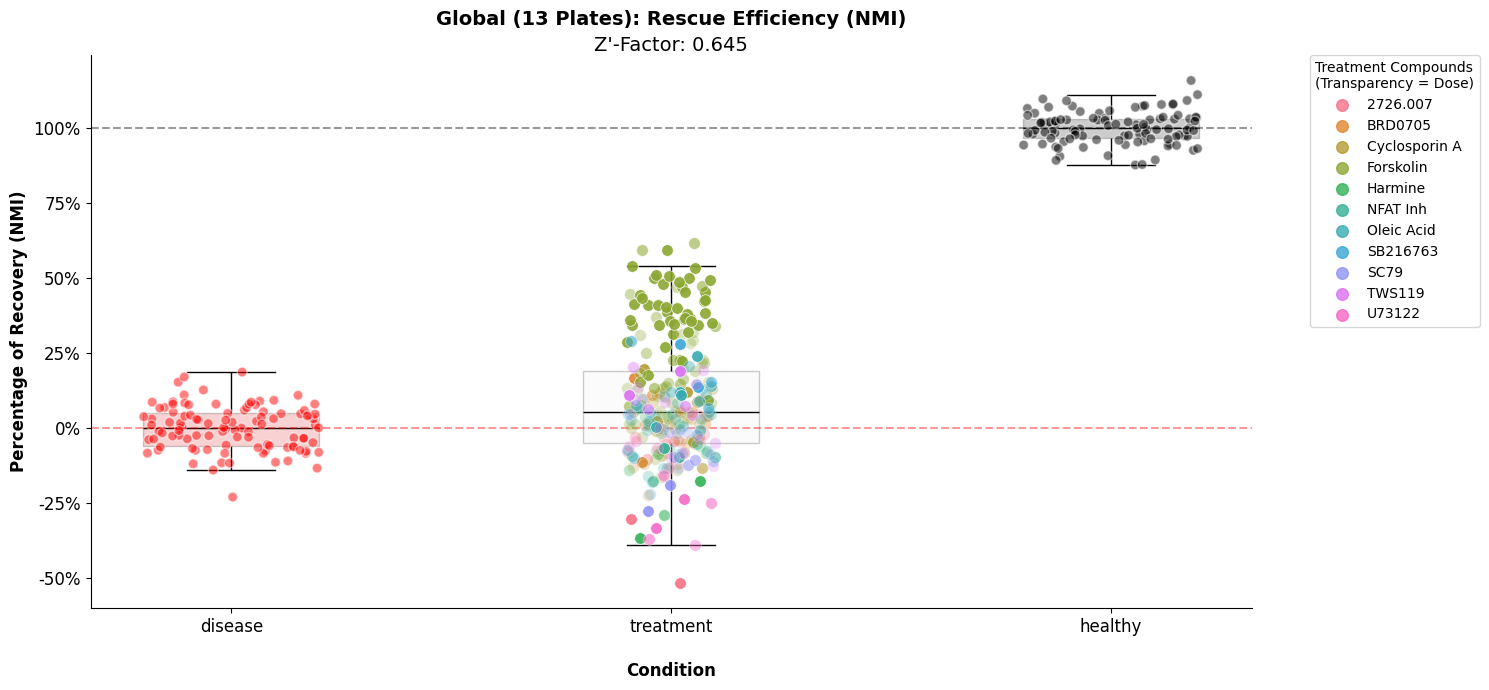

In [286]:
print("="*60)
print(f"1. COMPUTE NMI")
print("="*60)
print()

# Use level 'plate' to calculate NMI per plate or None to calculate globally
df_nmi = calculate_nmi(df_pca, n_pcs=10, level='plate')

# Plot (removed plate with low Z-factor - means unreliable separation between healthy and disease)
df_nmi = df_nmi[df_nmi["plate"] != "CE_CP_10X_9172025"]
plot_nmi_summary(df_nmi)